# Accordion 多粒度分块测试

验证新版 `_extract_accordion`（基于 HTML selector 的多粒度分块）在 4 种典型页面上的表现。

通过后再将代码复制到主 notebook Cell 19。

In [27]:
import re
from bs4 import BeautifulSoup
from langchain_text_splitters import RecursiveCharacterTextSplitter

_ALWAYS_REMOVE_TAGS = ["script", "style", "noscript", "iframe"]
_SKIP_CLASSES = re.compile(
    r"(site-header|site-footer|site-navigation|main-navigation|"
    r"breadcrumb|cookie|social-share|search-form|related-posts|"
    r"mega-menu|mobile-menu|skip-link)",
    re.IGNORECASE,
)

def _clean_soup(soup):
    for tag in _ALWAYS_REMOVE_TAGS:
        for el in soup.find_all(tag):
            el.decompose()
    _ROOT_TAGS = {"html", "head", "body"}
    for el in list(soup.find_all(True)):
        if el.name in _ROOT_TAGS:
            continue
        if not el.attrs:
            continue
        cls = " ".join(el.get("class", []))
        if _SKIP_CLASSES.search(cls):
            el.decompose()
    return soup

def _make_chunk(text, url, chunk_type, **meta):
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    if not text:
        return None
    return {
        "text": text,
        "metadata": {
            "source_url":  url,
            "chunk_type":  chunk_type,
            "heading":     meta.get("heading"),
            "sub_heading": meta.get("sub_heading"),
        },
    }

_ACCORDION_SUBSPLIT_CHARS = 1500
_FAQ_URL_RE  = re.compile(r"faq|faqs|frequently|q-and-a", re.IGNORECASE)
_FAQ_BODY_RE = re.compile(r"frequently asked|<details|<dt>", re.IGNORECASE)
_QUESTION_RE = re.compile(r".{10,}\?$")

def _subsplit_schedule(content_el, url, heading):
    chunks = []
    for quarter_div in content_el.select("div.quarter"):
        title_el = quarter_div.find(["h3", "h4", "strong"])
        sub_heading = title_el.get_text(strip=True) if title_el else quarter_div.get_text(" ", strip=True)[:60]
        body = quarter_div.get_text(separator="\n", strip=True)
        c = _make_chunk(f"{heading} — {sub_heading}\n{body}", url, "accordion_schedule",
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _subsplit_nested_accordion(content_el, url, heading):
    """课程页面 → accordion_course；FAQ 页面（URL 含 faq）→ accordion_faq。
    两者 HTML 结构相同，用 URL 区分。
    """
    chunks = []
    for li in content_el.select("ul.accordion li.accordion__item"):
        title_el = li.select_one(".accordion-title")
        body_el  = li.select_one(".accordion__content")
        if not title_el: continue
        sub_heading = title_el.get_text(strip=True)
        body = body_el.get_text(separator="\n", strip=True) if body_el else li.get_text(separator="\n", strip=True)
        chunk_type = "accordion_faq" if _FAQ_URL_RE.search(url) else "accordion_course"
        c = _make_chunk(f"{heading} — {sub_heading}\n{body}", url, chunk_type,
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _subsplit_jobs(content_el, url, heading):
    chunks = []
    textblock = content_el.select_one("div.textblock")
    if not textblock: return chunks
    current_h3, current_parts = None, []

    def _flush(h3_text, parts):
        body = "\n".join(parts).strip()
        if not body: return None
        return _make_chunk(f"{heading} — {h3_text}\n{body}", url, "accordion_job",
                           heading=heading, sub_heading=h3_text)

    for el in textblock.children:
        if not hasattr(el, "name") or el.name is None:
            t = str(el).strip()
            if t: current_parts.append(t)
            continue
        if el.name == "h3":
            if current_h3:
                c = _flush(current_h3, current_parts)
                if c: chunks.append(c)
            current_h3, current_parts = el.get_text(strip=True), []
        else:
            current_parts.append(el.get_text(separator="\n", strip=True))
    if current_h3:
        c = _flush(current_h3, current_parts)
        if c: chunks.append(c)
    return chunks

_ACCORDION_TEXT_SPLITTER = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)

def _subsplit_generic(content_el, url, heading):
    body = content_el.get_text(separator="\n", strip=True)
    chunks = []
    for i, t in enumerate(_ACCORDION_TEXT_SPLITTER.split_text(body)):
        sub_heading = f"{heading} (part {i+1})"
        c = _make_chunk(f"{heading}\n{t}", url, "accordion_sub",
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _choose_subsplitter(content_el):
    if content_el.select("div.quarter"):                      return _subsplit_schedule
    if content_el.select("ul.accordion li.accordion__item"): return _subsplit_nested_accordion
    if content_el.select("div.textblock h3"):                return _subsplit_jobs
    return None

def _has_accordion(soup):
    return bool(soup.select(".accordion-item, [data-accordion] > li"))

def _extract_accordion(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    chunks = []
    for item in soup.select(".accordion-item"):
        title_el   = item.select_one(".accordion-title")
        content_el = item.select_one(".accordion-content")
        if not title_el or not content_el: continue
        heading = title_el.get_text(strip=True)
        body    = content_el.get_text(separator="\n", strip=True)
        parent = _make_chunk(f"{heading}\n{body}", url, "accordion",
                             heading=heading, sub_heading=None)
        if parent: chunks.append(parent)
        if len(body) <= _ACCORDION_SUBSPLIT_CHARS:
            continue
        subsplitter = _choose_subsplitter(content_el) or _subsplit_generic
        chunks.extend(subsplitter(content_el, url, heading))
    return chunks

_TEXT_SPLITTER = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)

def _extract_paragraphs(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    plain = soup.get_text(separator="\n", strip=True)
    texts = _TEXT_SPLITTER.split_text(plain)
    return [c for c in (_make_chunk(t, url, "section") for t in texts) if c]

def _extract_faq(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    chunks = []
    for details in soup.find_all("details"):
        summary = details.find("summary")
        if not summary: continue
        question = summary.get_text(strip=True)
        summary.decompose()
        answer = details.get_text(separator=" ", strip=True)
        c = _make_chunk(f"Q: {question}\nA: {answer}", url, "faq", heading=question)
        if c: chunks.append(c)
    if not chunks:
        for dt in soup.find_all("dt"):
            dd = dt.find_next_sibling("dd")
            if dd:
                q = dt.get_text(strip=True)
                a = dd.get_text(separator=" ", strip=True)
                c = _make_chunk(f"Q: {q}\nA: {a}", url, "faq", heading=q)
                if c: chunks.append(c)
    if not chunks:
        for h in soup.find_all(["h2", "h3", "h4", "strong"]):
            q = h.get_text(strip=True)
            if not _QUESTION_RE.match(q): continue
            parts = []
            for sib in h.find_next_siblings():
                if sib.name in ("h2", "h3", "h4"): break
                parts.append(sib.get_text(separator=" ", strip=True))
            a = " ".join(parts).strip()
            if a:
                c = _make_chunk(f"Q: {q}\nA: {a}", url, "faq", heading=q)
                if c: chunks.append(c)
    return chunks

def extract_content(url, html):
    soup_probe = BeautifulSoup(html, "html.parser")
    if _has_accordion(soup_probe):
        chunks = _extract_accordion(html, url)
        if chunks: return chunks
    if _FAQ_URL_RE.search(url) or _FAQ_BODY_RE.search(html[:5000]):
        chunks = _extract_faq(html, url)
        if chunks: return chunks
    return _extract_paragraphs(html, url)

print('✅ 所有函数加载完成')

✅ 所有函数加载完成


In [28]:
# Cell 2：抓取 4 个代表性页面
import requests

test_pages = {
    "schedule": "https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/course-progressions/",
    "courses":  "https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/in-person-program/",
    "faq":      "https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/faqs/",
    "jobs":     "https://datascience.uchicago.edu/about/jobs/",
}
htmls = {k: requests.get(v, timeout=15).text for k, v in test_pages.items()}
print({k: f"{len(v):,} chars" for k, v in htmls.items()})

{'schedule': '174,307 chars', 'courses': '145,481 chars', 'faq': '129,457 chars', 'jobs': '114,735 chars'}


In [29]:
# 显示test_pages是schedule的chunk及其metadata
chunks = extract_content(test_pages["schedule"], htmls["schedule"])
for c in chunks[:5]:    
    print(f"--- {c['metadata']['chunk_type']} | {c['metadata']['heading']} | {c['metadata']['sub_heading']} | {c['metadata']['source_url']} ---")
    print(c["text"][:300], "\n")
        

--- accordion | Sample Full-Time Schedule | None | https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/course-progressions/ ---
Sample Full-Time Schedule
Prequarter
• 5 Weeks
Optional
Introduction to Statistical Concepts (Foundational)
Optional
This course is held in the 5 weeks leading up to the start of your first quarter and provides general exposure to basic statistical concepts that are necessary for students to underst 

--- accordion_schedule | Sample Full-Time Schedule | Prequarter | https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/course-progressions/ ---
Sample Full-Time Schedule — Prequarter
Prequarter
• 5 Weeks
Optional
Introduction to Statistical Concepts (Foundational)
Optional
This course is held in the 5 weeks leading up to the start of your first quarter and provides general exposure to basic statistical concepts that are necessary for studen 

--- accordion_schedule | Sample Full-Time Schedule | 

In [30]:
# Cell 3：对每个页面跑 extract_content()，打印类型分布
from collections import Counter

for page_type, url in test_pages.items():
    html = htmls[page_type]
    chunks = extract_content(url, html)
    types = Counter(c["metadata"]["chunk_type"] for c in chunks)
    print(f"\n{'='*60}")
    print(f"[{page_type.upper()}]  总 chunks: {len(chunks)}")
    print(f"  类型分布: {dict(types)}")
    for c in chunks[:3]:
        meta = c["metadata"]
        sub = (meta.get('sub_heading') or '')[:40]
        print(f"  type={meta['chunk_type']:22s}  heading={str(meta.get('heading',''))[:25]:25s}  sub={sub if sub else 'None'}")
        print(f"  len={len(c['text'])}  text[:80]: {c['text'][:80].replace(chr(10),' ')}")


[SCHEDULE]  总 chunks: 22
  类型分布: {'accordion': 3, 'accordion_schedule': 19}
  type=accordion               heading=Sample Full-Time Schedule  sub=None
  len=10210  text[:80]: Sample Full-Time Schedule Prequarter • 5 Weeks Optional Introduction to Statisti
  type=accordion_schedule      heading=Sample Full-Time Schedule  sub=Prequarter
  len=645  text[:80]: Sample Full-Time Schedule — Prequarter Prequarter • 5 Weeks Optional Introductio
  type=accordion_schedule      heading=Sample Full-Time Schedule  sub=Quarter 1
  len=3260  text[:80]: Sample Full-Time Schedule — Quarter 1 Quarter 1 • 10 Weeks Optional Python for D

[COURSES]  总 chunks: 33
  类型分布: {'accordion': 3, 'accordion_course': 30}
  type=accordion               heading=Noncredit Courses          sub=None
  len=2362  text[:80]: Noncredit Courses Career Seminar (Seminar, required) The Pass/Fail Career Semina
  type=accordion_course        heading=Noncredit Courses          sub=Career Seminar (Seminar, required)
  len=467  text[:

In [31]:
# Cell 4：专项验证 — Core Courses 多粒度
url = test_pages["courses"]
html = htmls["courses"]
chunks = extract_content(url, html)

parents = [c for c in chunks if c["metadata"]["chunk_type"] == "accordion"
           and c["metadata"].get("heading") == "Core Courses"]
subs    = [c for c in chunks if c["metadata"]["chunk_type"] == "accordion_course"
           and c["metadata"].get("heading") == "Core Courses"]

print(f"Core Courses parent chunks: {len(parents)}")
print(f"Core Courses sub-chunks:    {len(subs)}")
print()
for c in subs:
    print(f"  sub_heading={c['metadata']['sub_heading']!r}  len={len(c['text'])}")

assert len(parents) >= 1, "❌ parent chunk 缺失"
assert len(subs) >= 3, f"❌ sub-chunks 太少（{len(subs)}），期望 ≥ 3"
print("\n✅ Core Courses 多粒度验证通过")

Core Courses parent chunks: 1
Core Courses sub-chunks:    7

  sub_heading='Time Series Analysis and Forecasting'  len=228
  sub_heading='Statistical Models for Data Science'  len=809
  sub_heading='Machine Learning I'  len=661
  sub_heading='Machine Learning II'  len=559
  sub_heading='Data Engineering Platforms for Analytics or Big Data and Cloud Computing'  len=512
  sub_heading='Leadership and Consulting for Data Science'  len=813
  sub_heading='Data Science Capstone Project'  len=314

✅ Core Courses 多粒度验证通过


In [32]:
# Cell 5：专项验证 — Schedule quarter 分割
url = test_pages["schedule"]
html = htmls["schedule"]
chunks = extract_content(url, html)

schedule_subs = [c for c in chunks if c["metadata"]["chunk_type"] == "accordion_schedule"]
print(f"accordion_schedule sub-chunks: {len(schedule_subs)}")
for c in schedule_subs[:8]:
    print(f"  heading={c['metadata']['heading']!r:35}  sub_heading={c['metadata']['sub_heading']!r}  len={len(c['text'])}")

assert len(schedule_subs) >= 5, f"❌ schedule sub-chunks 太少（{len(schedule_subs)}）"
print("\n✅ Schedule quarter 分割验证通过")

accordion_schedule sub-chunks: 19
  heading='Sample Full-Time Schedule'          sub_heading='Prequarter'  len=645
  heading='Sample Full-Time Schedule'          sub_heading='Quarter 1'  len=3260
  heading='Sample Full-Time Schedule'          sub_heading='Quarter 2'  len=2116
  heading='Sample Full-Time Schedule'          sub_heading='Quarter 3'  len=2105
  heading='Sample Full-Time Schedule'          sub_heading='Quarter 4'  len=2245
  heading='Sample Part-Time Schedule'          sub_heading='Prequarter'  len=645
  heading='Sample Part-Time Schedule'          sub_heading='Quarter 1'  len=2017
  heading='Sample Part-Time Schedule'          sub_heading='Quarter 2'  len=955

✅ Schedule quarter 分割验证通过


In [33]:
# Cell 6：专项验证 — Jobs h3 分割
url = test_pages["jobs"]
html = htmls["jobs"]
chunks = extract_content(url, html)

job_subs = [c for c in chunks if c["metadata"]["chunk_type"] == "accordion_job"]
print(f"accordion_job sub-chunks: {len(job_subs)}")
for c in job_subs:
    print(f"  heading={c['metadata']['heading']!r:15}  sub_heading={c['metadata']['sub_heading']!r}  len={len(c['text'])}")

assert len(job_subs) >= 3, f"❌ job sub-chunks 太少（{len(job_subs)}）"
print("\n✅ Jobs h3 分割验证通过")

accordion_job sub-chunks: 14
  heading='Faculty'        sub_heading='Associate Professor of Data Science'  len=583
  heading='Faculty'        sub_heading='Assistant Professor of Data Science'  len=588
  heading='Faculty'        sub_heading='Instructional Professor (open rank) in Data Science'  len=1059
  heading='Postdoctoral'   sub_heading='Data and Democracy Postdoctoral Scholar'  len=1255
  heading='Postdoctoral'   sub_heading='Data Science Preceptor'  len=1296
  heading='Postdoctoral'   sub_heading='Data Science Institute Postdoctoral Scholars Program AY2026-27'  len=1870
  heading='Graduate'       sub_heading='MS in Applied Data Science'  len=299
  heading='Graduate'       sub_heading='MS in Computational Analysis and Public Policy (MSCAPP)'  len=339
  heading='Graduate'       sub_heading='MS in Data Science'  len=299
  heading='Graduate'       sub_heading='MBA/MS in Applied Data Science'  len=917
  heading='Staff'          sub_heading='Systems Administrator 3'  len=1077
  heading

In [34]:
# Cell 7：兜底检查 — 是否有 accordion_sub（理想情况为 0）
all_chunks = []
for page_type, url in test_pages.items():
    all_chunks.extend(extract_content(url, htmls[page_type]))

fallback = [c for c in all_chunks if c["metadata"]["chunk_type"] == "accordion_sub"]
print(f"accordion_sub (兜底触发): {len(fallback)}")
if fallback:
    print("⚠️  以下 chunk 使用了兜底分割（检查 HTML 结构是否符合预期）：")
    for c in fallback:
        print(f"  heading={c['metadata']['heading']!r}  url={c['metadata']['source_url'][-50:]}")
else:
    print("✅ 所有大 accordion 都命中了专属 selector，兜底未触发")

accordion_sub (兜底触发): 0
✅ 所有大 accordion 都命中了专属 selector，兜底未触发


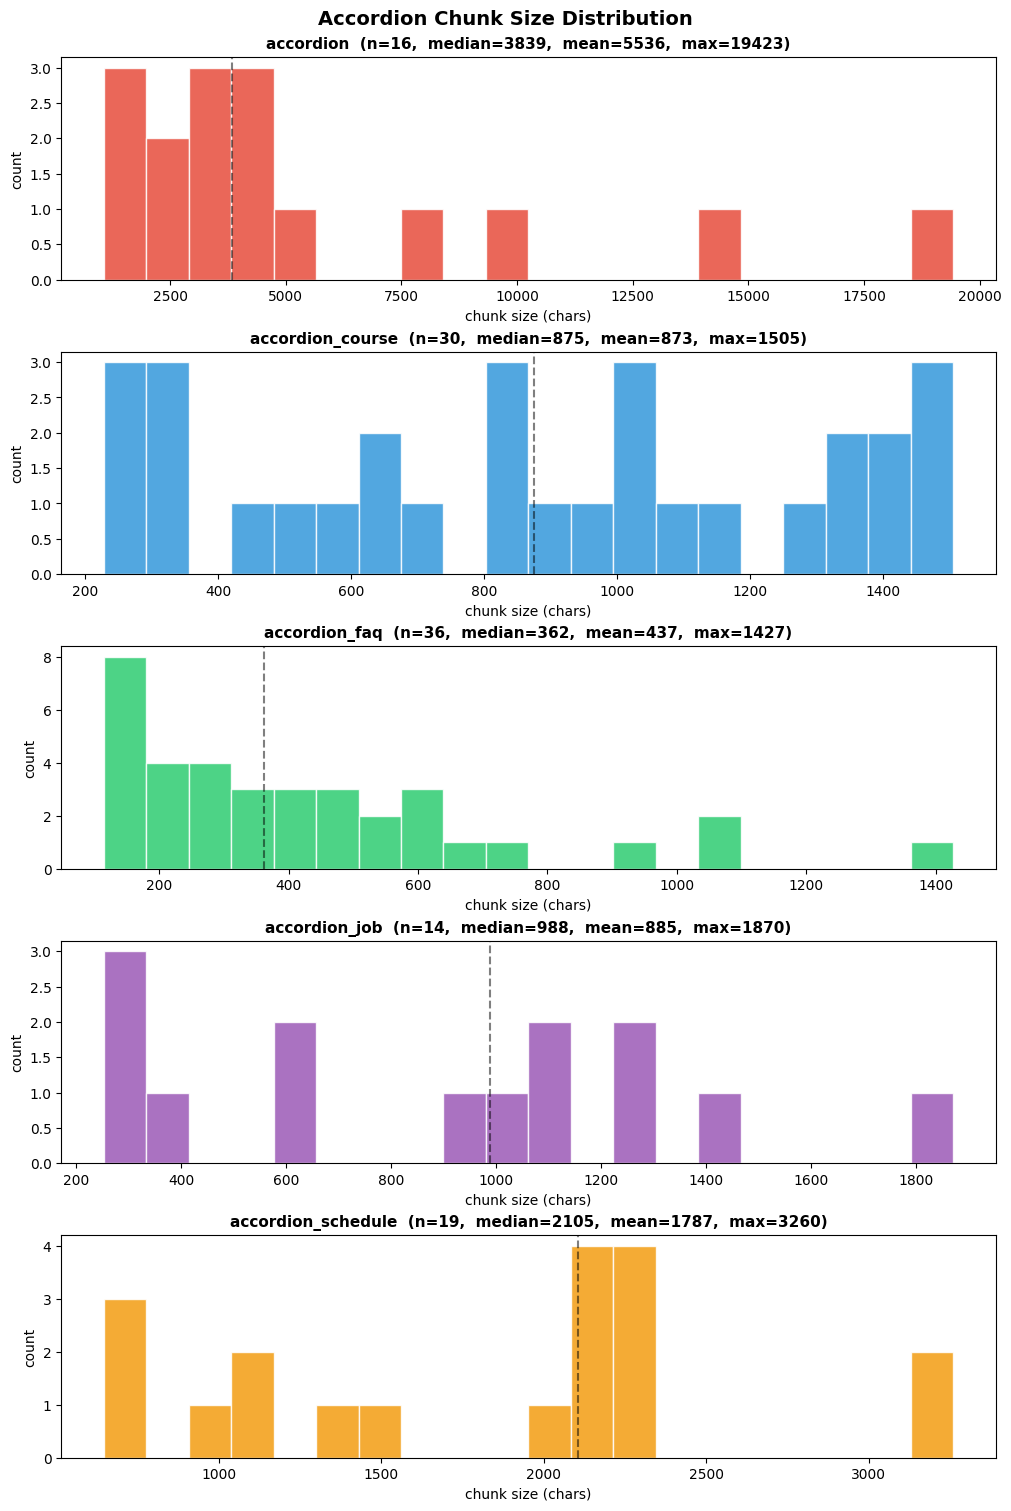

In [35]:
# Cell 9：accordion_xx chunk 大小分布图
import matplotlib.pyplot as plt
import numpy as np

# 收集所有 4 个测试页面的 accordion chunks
all_chunks = []
for page_type, url in test_pages.items():
    all_chunks.extend(extract_content(url, htmls[page_type]))

# 按 chunk_type 分组（只保留 accordion 开头的）
acc_types = {}
for c in all_chunks:
    ct = c["metadata"]["chunk_type"]
    if ct.startswith("accordion"):
        acc_types.setdefault(ct, []).append(len(c["text"]))

colors = {
    "accordion": "#e74c3c",
    "accordion_course": "#3498db",
    "accordion_faq": "#2ecc71",
    "accordion_schedule": "#f39c12",
    "accordion_job": "#9b59b6",
    "accordion_sub": "#95a5a6",
}

fig, axes = plt.subplots(len(acc_types), 1, figsize=(10, 3 * len(acc_types)), constrained_layout=True)
if len(acc_types) == 1:
    axes = [axes]

for ax, (ct, sizes) in zip(axes, sorted(acc_types.items())):
    color = colors.get(ct, "#7f8c8d")
    ax.hist(sizes, bins=20, color=color, edgecolor="white", alpha=0.85)
    med = np.median(sizes)
    ax.axvline(med, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"{ct}  (n={len(sizes)},  median={med:.0f},  mean={np.mean(sizes):.0f},  max={max(sizes)})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("chunk size (chars)")
    ax.set_ylabel("count")

fig.suptitle("Accordion Chunk Size Distribution", fontsize=14, fontweight="bold")
plt.show()

In [36]:
# Cell 8：验证所有含 accordion 的页面
import json as _json, requests
from bs4 import BeautifulSoup
from collections import Counter

# 从已保存的 JSON 加载所有爬取页面
with open('uchicago_ads_pages_depth3.json') as f:
    all_pages = _json.load(f)

print(f'总页面数: {len(all_pages)}')

results = []
for page in all_pages:
    url  = page['url']
    html = page.get('_raw_html', '')
    if not html:
        try:
            html = requests.get(url, timeout=10).text
        except Exception:
            html = ''
    if not html:
        continue

    soup = BeautifulSoup(html, 'html.parser')
    if not soup.select('.accordion-item'):
        continue

    chunks = extract_content(url, html)
    type_counts = Counter(c['metadata']['chunk_type'] for c in chunks)
    has_fallback = type_counts.get('accordion_sub', 0) > 0

    results.append({
        'url': url,
        'chunks': len(chunks),
        'types': dict(type_counts),
        'fallback': has_fallback,
    })

print(f'\n含 accordion 的页面: {len(results)}\n')
print(f"{'':3}{'URL':<70}  {'chunks':>6}  {'类型分布'}")
print('-' * 120)
for r in results:
    flag = '⚠️  ' if r['fallback'] else '✅ '
    print(f"{flag}{r['url'][-68:]:<68}  {r['chunks']:>6}  {r['types']}")

fallback_pages = [r for r in results if r['fallback']]
print(f'\n兜底触发页面数: {len(fallback_pages)} / {len(results)}')


总页面数: 147

含 accordion 的页面: 8

   URL                                                                     chunks  类型分布
------------------------------------------------------------------------------------------------------------------------
✅ https://datascience.uchicago.edu/about/jobs/                              19  {'accordion': 5, 'accordion_job': 14}
✅ ation/masters-programs/ms-in-applied-data-science/in-person-program/      33  {'accordion': 3, 'accordion_course': 30}
✅ ation/masters-programs/ms-in-applied-data-science/online-program/%20      30  {'accordion': 3, 'accordion_course': 27}
✅ ion/masters-programs/ms-in-applied-data-science/course-progressions/      22  {'accordion': 3, 'accordion_schedule': 19}
✅ tascience.uchicago.edu/education/masters-programs/in-person-program/      33  {'accordion': 3, 'accordion_course': 30}
✅ /datascience.uchicago.edu/education/masters-programs/online-program/      30  {'accordion': 3, 'accordion_course': 27}
✅ cago.edu/education/masters-progra